# **Customer Churn Prediction & Business Insights**

*Predict customer churn and identify key drivers to improve retention strategies.* 

TL;DR

### **Business Overview**

Customer churn is a critical challenge in the energy and utilities industry due to high acquisition costs, long contract cycles, and low profit margins.

Even a small increase in churn can lead to significant revenue loss, making early identification of at-risk customers a key business priority.

### **Problem Statement**

This project aims to identify and predict customer churn by answering key business questions:

- Which customers are most likely to leave?
- Does pricing significantly influence churn behavior?
- How does energy consumption relate to churn?
- Can high-risk customers be identified before contract termination?

### **Key Findings**

- Customer churn is strongly influenced by **tenure**, with newer customers significantly more likely to leave.
- **Price-related features have limited direct impact**, indicating churn is not purely price-driven.
- **Consumption patterns alone are weak predictors**, but become useful when combined with behavioral and contract features.
- Customers with **gas subscriptions show lower churn**, suggesting bundling improves retention.
- The dataset is highly imbalanced (~90% non-churn), requiring careful model evaluation using recall and F1-score.

### **Model Performance**

- Best Model: Random Forest
- Accuracy: 0.87  
- F1-score: 0.31  
- Recall (Churn): 0.30 

The model prioritizes identifying churn customers (recall) over overall accuracy, aligning with business needs where missing a churn customer is more costly than a false positive.

### **Business Impact**

This solution enables:

- Early identification of high-risk customers  
- Targeted retention and engagement strategies  
- Data-driven decision-making for contract renewals  
- Improved customer segmentation 

---

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay

# shows plots in jupyter notebook
%matplotlib inline

#set plot style
sns.set(color_codes=True)

### **Dataset Overview**

This project uses two datasets provided by an energy utility company to analyze customer behavior and predict customer churn.

`1. Client Dataset`

The client dataset contains customer-level information including electricity and gas consumption, contract details, pricing forecasts, and churn status.

`2. Price Dataset`

The price dataset contains historical electricity pricing information across different pricing periods (off-peak, peak, and mid-peak). This dataset helps analyze how price variations influence customer churn behavior.

In [3]:
#Data Loading
client=pd.read_csv(r"C:\Users\hanan\Downloads\client_data (1).csv")
price=pd.read_csv(r"C:\Users\hanan\Downloads\price_data (1).csv")

## **Client Exploratory Data Analysis**

### **Client Dataset Features**

| Feature | Description |
|--------|-------------|
| id | Unique identifier for each client |
| activity_new | Category of the company's activity |
| channel_sales | Code representing the sales channel |
| cons_12m | Electricity consumption over the past 12 months |
| cons_gas_12m | Gas consumption over the past 12 months |
| cons_last_month | Electricity consumption during the last month |
| date_activ | Date of contract activation |
| date_end | Registered contract end date |
| date_modif_prod | Date of the last modification of the product |
| date_renewal | Date of the next contract renewal |
| forecast_cons_12m | Forecasted electricity consumption for the next 12 months |
| forecast_cons_year | Forecasted electricity consumption for the next calendar year |
| forecast_discount_energy | Forecasted value of current energy discount |
| forecast_meter_rent_12m | Forecasted meter rental bill for the next 12 months |
| forecast_price_energy_off_peak | Forecasted energy price for off-peak period |
| forecast_price_energy_peak | Forecasted energy price for peak period |
| forecast_price_pow_off_peak | Forecasted power price for off-peak period |
| has_gas | Indicates whether the client is also a gas customer |
| imp_cons | Current paid consumption |
| margin_gross_pow_ele | Gross margin on power subscription |
| margin_net_pow_ele | Net margin on power subscription |
| nb_prod_act | Number of active products and services |
| net_margin | Total net margin generated by the client |
| num_years_antig | Number of years the client has been with the company |
| origin_up | Code of the electricity campaign the client first subscribed to |
| pow_max | Subscribed maximum power |
| churn | Target variable indicating whether the client churned in the next 3 months |

In [4]:
client.head(2)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0


### **Data Quality Assessment**

In [5]:
client.shape

#Data Type Consistency Check
client.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [6]:
#missing values check
client.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64

In [7]:
# Duplicate Records check
client.duplicated().sum()

0

### **Dataset Churn Distribution**

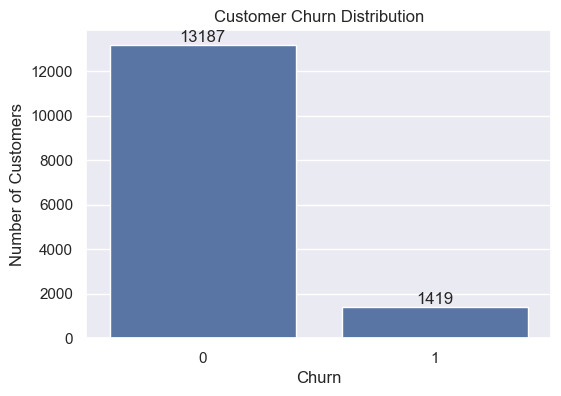

In [8]:
# Churn Distribution based on energy

plt.figure(figsize=(6,4))
ax = sns.countplot(x="churn", data=client)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
    
plt.show()

- Strong class imbalance (~90% non-churn)
- Requires handling during modeling (class weights)

### **Energy Consumption Distribution**

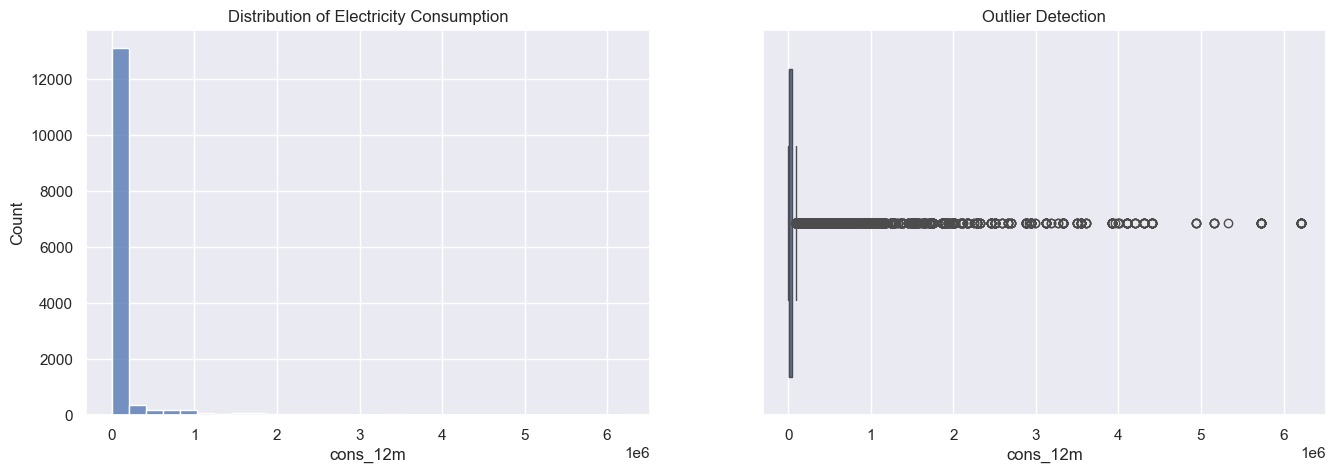

Number of outliers: 2084
percentage of outliers: 14.268108996302889


In [9]:
#Outlier Detection For Electricity Consumption

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(client["cons_12m"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Electricity Consumption")

# Boxplot Visualization
sns.boxplot(x=client["cons_12m"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = client["cons_12m"].quantile(0.25)
Q3 = client["cons_12m"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = client[
    (client["cons_12m"] < min) |
    (client["cons_12m"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(client))*100)

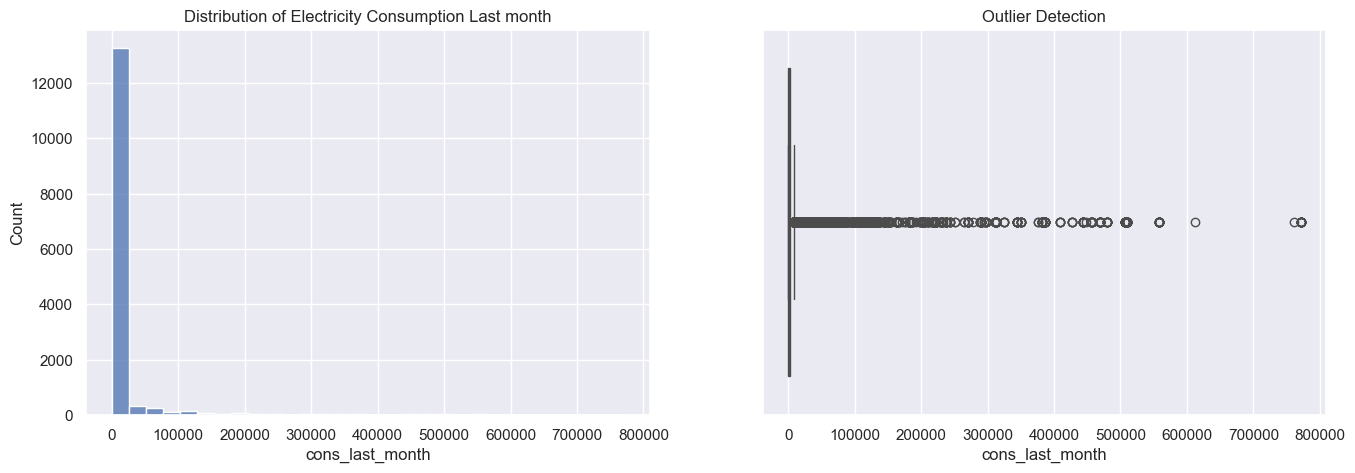

Number of outliers: 2051
percentage of outliers: 14.042174448856635


In [10]:
#Outlier Detection For Electricity Consumption Last month

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(client["cons_last_month"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Electricity Consumption Last month")

# Boxplot Visualization
sns.boxplot(x=client["cons_last_month"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = client["cons_last_month"].quantile(0.25)
Q3 = client["cons_last_month"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = client[
    (client["cons_last_month"] < min) |
    (client["cons_last_month"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(client))*100)

- Consumption features are highly skewed
- The relatively high proportion of outliers suggests that these values are not merely noise, but may represent distinct customer segments such as high-consumption or industrial users.

>**Given their potential business significance, outliers should not be removed blindly.**  

Instead, transformations (e.g., log scaling) or segmentation approaches should be used to handle them appropriately.

### **Energy Consumption Churn Analysis**

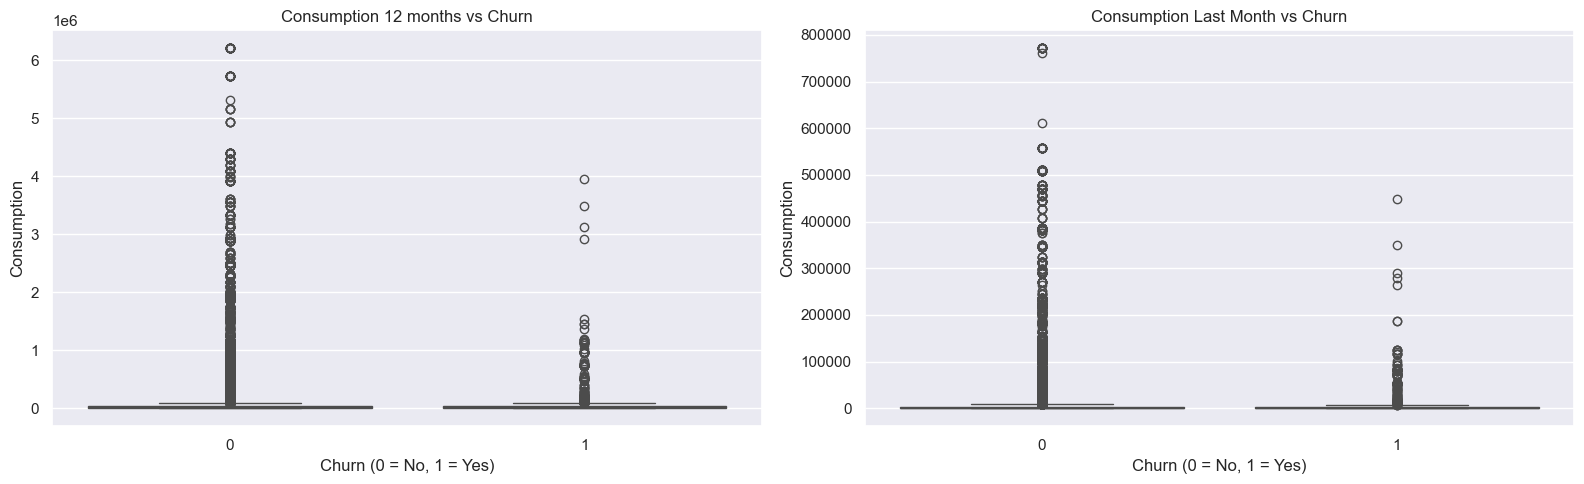

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# 12 months consumption
sns.boxplot(x="churn", y="cons_12m", data=client, ax=axes[0])
axes[0].set_title("Consumption 12 months vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Consumption")

# Last month consumption
sns.boxplot(x="churn", y="cons_last_month", data=client, ax=axes[1])
axes[1].set_title("Consumption Last Month vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Consumption")

plt.tight_layout()
plt.show()

- Both 12-month and last-month consumption distributions are **highly right-skewed**, with a large number of extreme outliers.
- Most customers have very low consumption values, while a small number exhibit extremely high usage.

> **Next Steps:** Apply **log transformation** to reduce skewness and stabilize variance.

### **Gas Consumption Distribution Analysis**

In [12]:
client["has_gas"] = client["has_gas"].map({"t": True, "f": False})
client = client.copy()

# Split the gas users
gas_clients = client[client["has_gas"] == True].copy()
non_gas_clients = client[client["has_gas"] == False].copy()


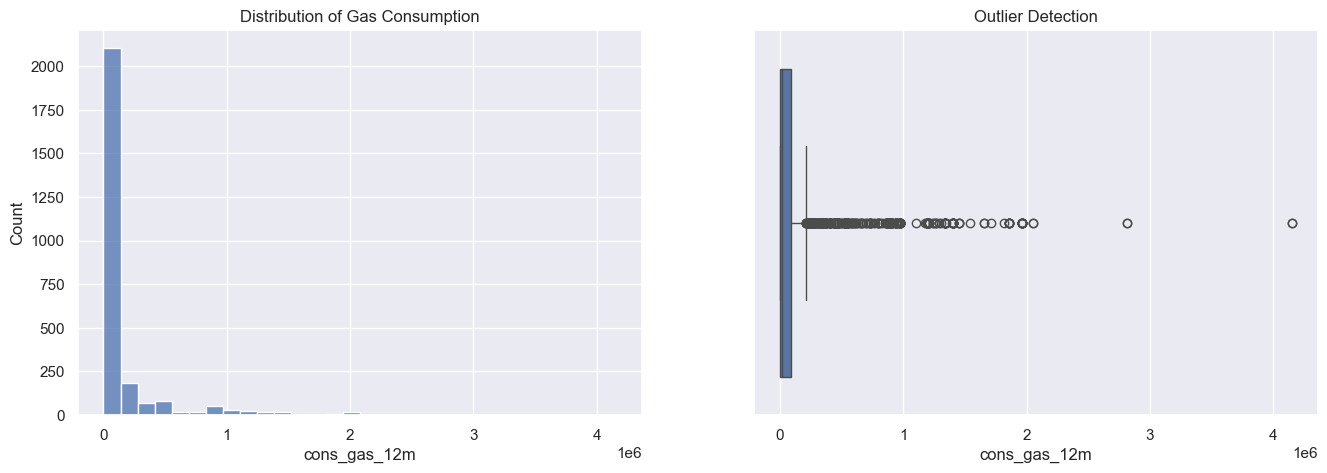

Number of outliers: 422
percentage of outliers: 15.918521312712183


In [13]:
#Outlier Detection For Gas Consumption

fig, axes = plt.subplots(1,2, figsize=(16,5))

# Histogram Visualization 
sns.histplot(gas_clients["cons_gas_12m"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Gas Consumption")

# Boxplot Visualization
sns.boxplot(x=gas_clients["cons_gas_12m"], ax=axes[1])
axes[1].set_title("Outlier Detection")

plt.show()

# Calculate IQR
Q1 = gas_clients["cons_gas_12m"].quantile(0.25)
Q3 = gas_clients["cons_gas_12m"].quantile(0.75)

IQR = Q3 - Q1

min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR

outliers = gas_clients[
    (gas_clients["cons_gas_12m"] < min) |
    (gas_clients["cons_gas_12m"] > max)
]

#No of outliers
print("Number of outliers:", len(outliers))

#Percentage of outliers
print("percentage of outliers:", (len(outliers)/len(gas_clients))*100)

- The distribution is highly right-skewed, with most customers having very low consumption and a small subset exhibiting extremely high usage.

- This skewness is further amplified by the fact that **not all customers use gas services**, resulting in a concentration of low or zero values.

- The relatively high proportion of outliers suggests that these observations likely represent **distinct customer segments**, such as high-usage households or commercial/industrial consumers.

> **Given their potential business significance, outliers should not be removed blindly.** 

Instead, appropriate techniques such as log transformation or customer segmentation should be applied to better capture underlying consumption patterns.

### **Gas Consumption Churn Analysis**

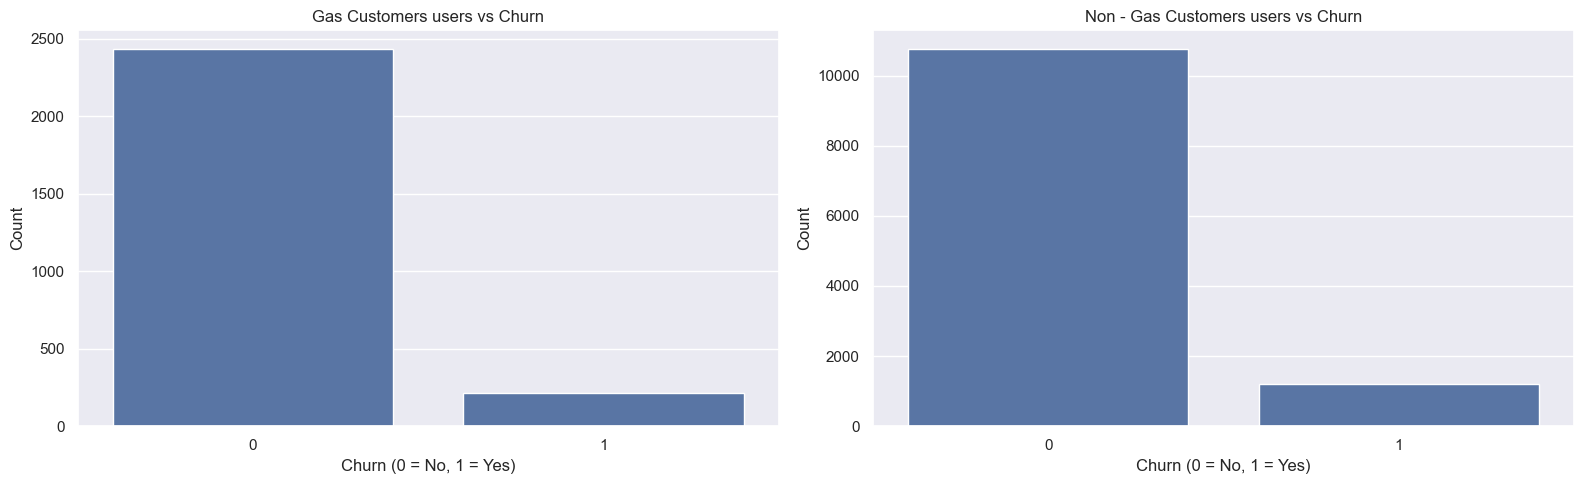

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Gas Customers v/s churn
sns.countplot(x="churn", data=gas_clients, ax=axes[0])
axes[0].set_title("Gas Customers users vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

# Non Gas Customers v/s churn
sns.countplot(x="churn", data=non_gas_clients, ax=axes[1])
axes[1].set_title("Non - Gas Customers users vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

- Non-gas customers contribute to a higher absolute number of churn cases

> **While gas subscription appears to have a protective effect against churn, it is not a definitive standalone predictor**. 

This suggests that service bundling plays a role in retention, but churn behavior is also influenced by other factors such as pricing sensitivity, contract duration, and overall customer engagement.

### **Customer Engagement Churn Analysis**

In [15]:
#No .of products
client.nb_prod_act.value_counts()

nb_prod_act
1     11431
2      2445
3       523
4       150
5        31
9        11
6         8
8         4
10        2
32        1
Name: count, dtype: int64

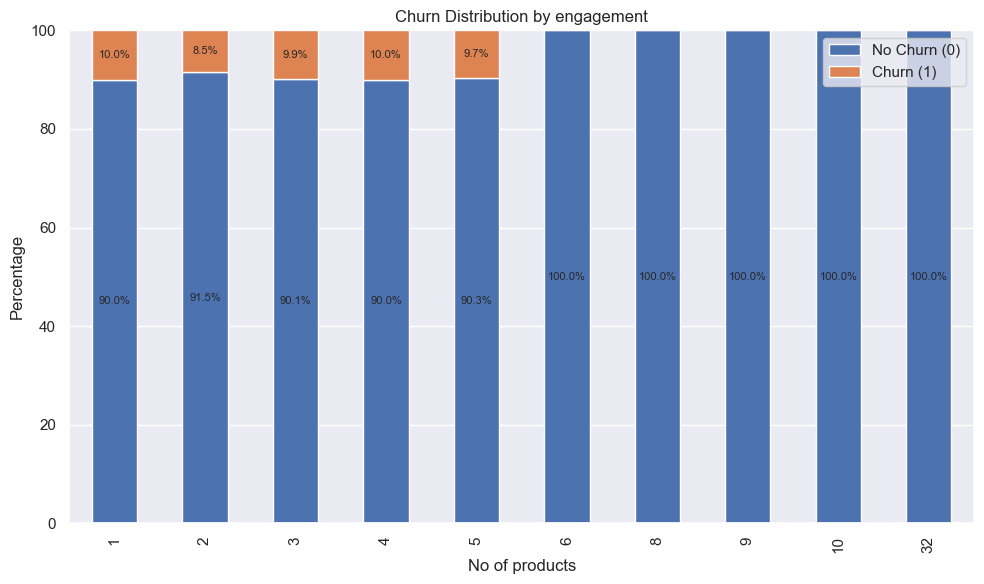

In [16]:
# Create aggregation table
engagement = (client.groupby(['nb_prod_act', 'churn']).size().unstack(fill_value=0))

# Total customers per channel ( total = churn + no churn )
engagement_count = engagement.sum(axis=1)

# Counts to percentage( nochurn% = nochurn/total )
engagement_churn = engagement.div(engagement_count, axis=0) * 100

# Plot engagement
ax = engagement_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6))

# Annotate each segment
for i, (index, row) in enumerate(engagement_churn.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val / 2, f"{val:.1f}%",
                ha='center', va='center', fontsize = 8)
            cumulative += val
                
plt.title("Churn Distribution by engagement")
plt.xlabel("No of products")
plt.ylabel("Percentage")
plt.legend(["No Churn (0)", "Churn (1)"])
plt.tight_layout()
plt.show()

- There is no strong decreasing trend in churn as the number of products increases within this range.
- The segments with 6+ products have very few observations, which may lead to unreliable or misleading conclusions.
- The apparent 0% churn in these groups is likely due to low sample size rather than a true business pattern.

> The number of products alone does not show a strong or consistent relationship with churn in its raw form.

### **Tenure Churn Analysis**

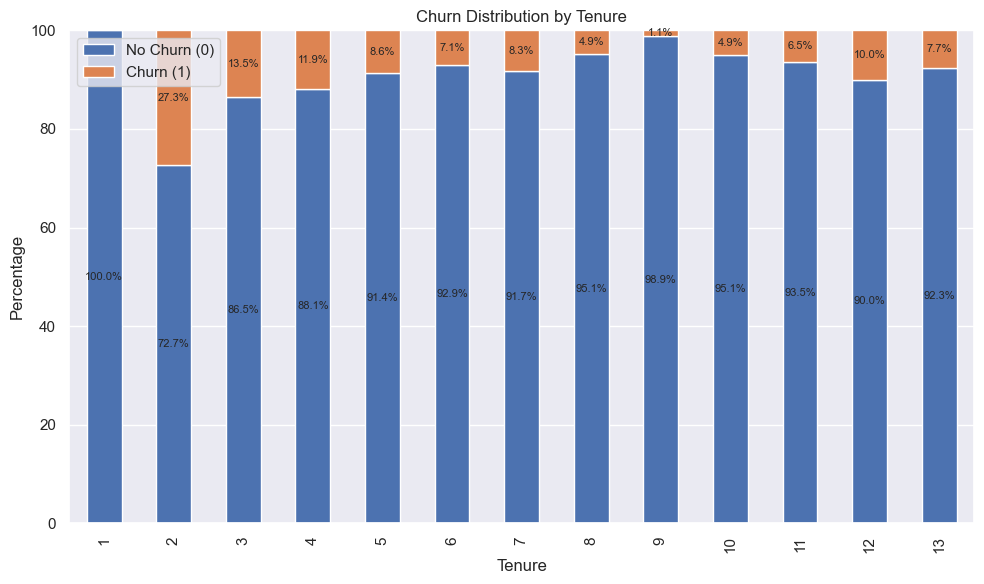

In [17]:
# Create aggregation table
tenure = (client.groupby(['num_years_antig', 'churn']).size().unstack(fill_value=0))

# Total customers per channel ( total = churn + no churn )
tenure_count = tenure.sum(axis=1)

# Counts to percentage( nochurn% = nochurn/total )
tenure_churn = tenure.div(tenure_count, axis=0) * 100

# Plot tenure
ax = tenure_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6))

# Annotate each segment
for i, (index, row) in enumerate(tenure_churn.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(
                i,
                cumulative + val / 2, f"{val:.1f}%",
                ha='center', va='center', fontsize = 8)
            cumulative += val
                
plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Percentage")
plt.legend(["No Churn (0)", "Churn (1)"])
plt.tight_layout()
plt.show()

> Customer tenure has a strong inverse relationship with churn — newer customers are significantly more likely to leave than long-term customers.

### **Profitability Features**

In [18]:
client[["margin_gross_pow_ele",
    "margin_net_pow_ele",
    "net_margin"]].corr()

,margin_gross_pow_ele,margin_net_pow_ele,net_margin
margin_gross_pow_ele,1.000000,0.999914,0.031814
margin_net_pow_ele,0.999914,1.000000,0.031639
net_margin,0.031814,0.031639,1.000000


- Potential redundancy → useful for feature selection

### **Time - Based Analysis**

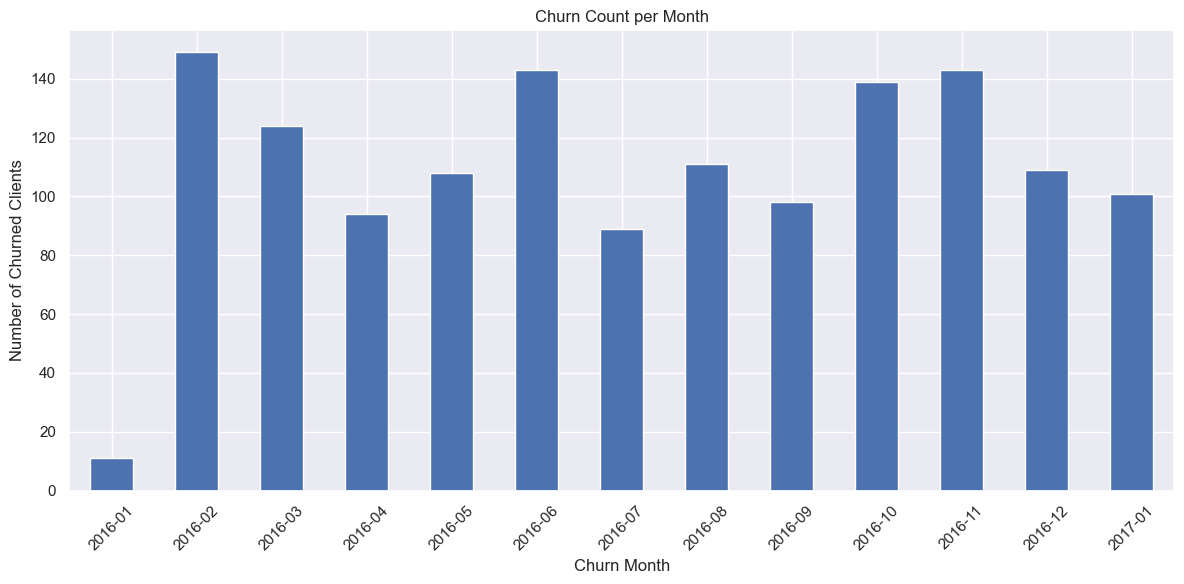

In [19]:
# Convert to datetime
client["date_end"] = pd.to_datetime(client["date_end"], errors="coerce")

# Filter churn customers
clients_churned = client[client["churn"] == 1].copy()

# Extract churn month from 'date_end'
clients_churned["churn_month"] = clients_churned["date_end"].dt.to_period("M")

# Count churns per month
churn_per_month = clients_churned["churn_month"].value_counts().sort_index()

# Plot churn count per month
churn_per_month.plot(kind='bar', figsize=(12,6), title='Churn Count per Month')
plt.xlabel("Churn Month")
plt.ylabel("Number of Churned Clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Churn does not follow a strong seasonal trend but shows moderate fluctuations across months.**

# **Price Exploratory Data Analysis**

### **Price Dataset Features**

| Feature | Description |
|--------|-------------|
| id | client company identifier |
| price_date | reference date |
| price_off_peak_var | price of energy for the 1st period (off peak) |
| price_peak_var | price of energy for the 2nd period (peak) |
| price_mid_peak_var | price of energy for the 3rd period (mid peak) |
| price_off_peak_fix | price of power for the 1st period (off peak) |
| price_peak_fix | price of power for the 1st period (off peak) |
| price_mid_peak_fix | price of power for the 3rd period (mid peak)

In [20]:
price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


### **Data Quality Assessment**

In [21]:
price.shape

#Data Type Consistency Check
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 19.5 MB


In [22]:
# Convert all columns to numeric
price_cols = [
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

price[price_cols] = price[price_cols].apply(pd.to_numeric, errors='coerce')

In [23]:
price["price_date"] = pd.to_datetime(price["price_date"])

In [24]:
#missing values check
price.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [25]:
# Duplicate Records check
client.duplicated().sum()

0

In [26]:
price.describe()

,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


### **Time-Based Analysis**

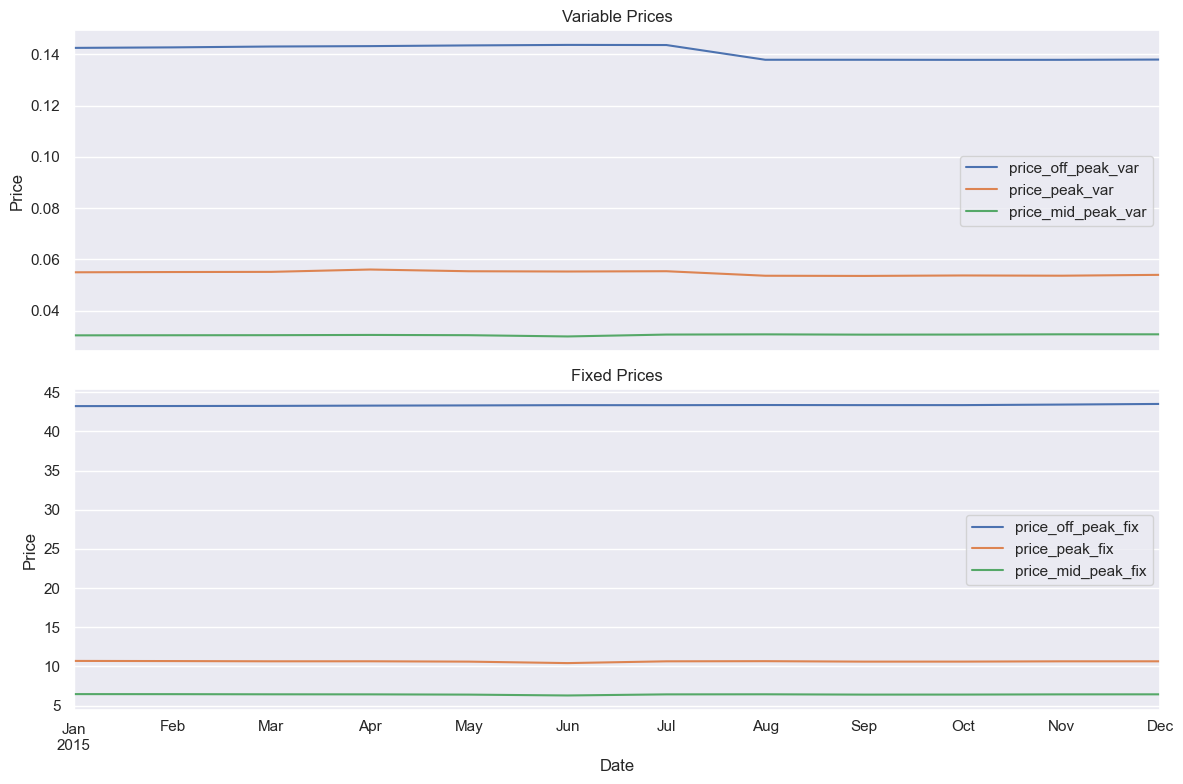

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Variable prices plot
price.groupby('price_date')[price_cols[:3]].mean().plot(
    ax=axes[0],
    title='Variable Prices'
)
axes[0].set_ylabel('Price')
axes[0].grid(True)

# Fixed prices plot
price.groupby('price_date')[price_cols[3:]].mean().plot(
    ax=axes[1],
    title='Fixed Prices'
)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price')
axes[1].grid(True)

plt.tight_layout()
plt.show()

- Slight dip observed around mid-year (July–August) in off-peak and peak variable prices, but overall trend remains stable
- **Fixed prices dominate the pricing structure**
- **Fixed pricing is highly stable throughout the year**, indicating minimal volatility and likely regulated or contract-based pricing
- No strong seasonality or trend patterns observed in either variable or fixed prices
- **Clear price hierarchy across periods**: off-peak > peak > mid-peak (consistent in both variable and fixed components)

### **Distribution Analysis**

array([[<Axes: title={'center': 'price_off_peak_var'}>,
        <Axes: title={'center': 'price_peak_var'}>],
       [<Axes: title={'center': 'price_mid_peak_var'}>, <Axes: >]],
      dtype=object)

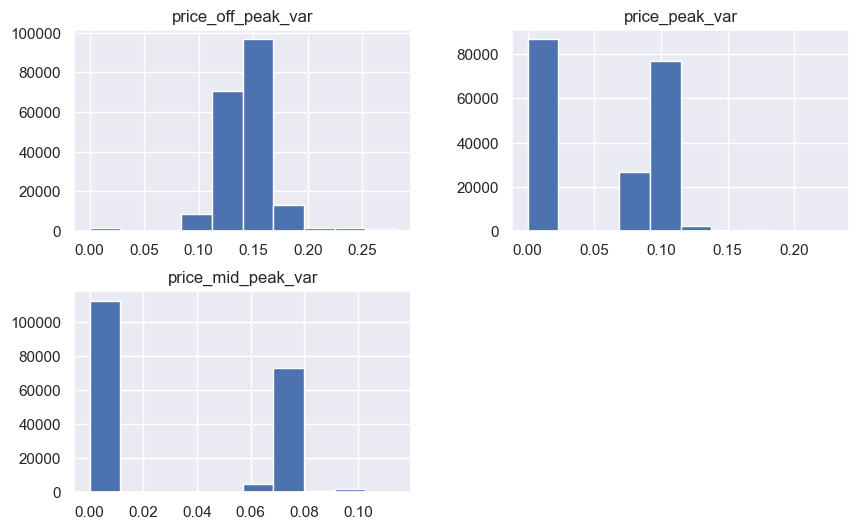

In [28]:
price_var = ['price_off_peak_var','price_peak_var','price_mid_peak_var']
price[price_var].hist(figsize=(10,6))

- **price_mid_peak_var is heavily zero-dominated** indicating limited usage or availability of this tariff
- Strong presence of zero values introduces **high skewness in peak and mid-peak distributions**
- **Off-peak pricing appears stable** and widely applied, while **peak and mid-peak pricing are inconsistent** across customers
- **Distribution patterns confirm heterogeneous pricing structure**, likely due to different contract types or customer segmentation

array([[<Axes: title={'center': 'price_off_peak_fix'}>,
        <Axes: title={'center': 'price_peak_fix'}>],
       [<Axes: title={'center': 'price_mid_peak_fix'}>, <Axes: >]],
      dtype=object)

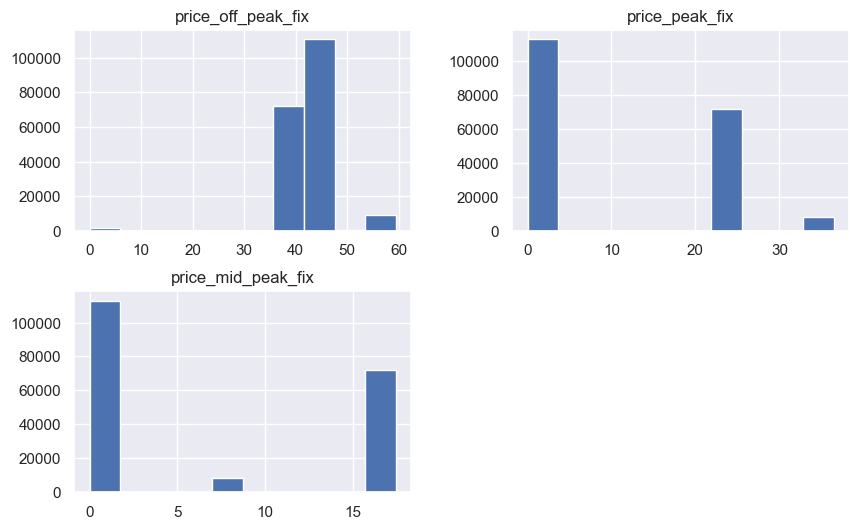

In [29]:
price_fix = ['price_off_peak_fix','price_peak_fix','price_mid_peak_fix']
price[price_fix].hist(figsize=(10,6))

- Minor spread toward higher values suggests limited premium or outlier pricing tiers
- Off-peak fixed pricing appears universally applied, while peak and mid-peak are conditional or optional components
- Distributions are highly skewed for peak and mid-peak, but relatively stable and normal-like for off-peak
- Clear segmentation suggests different pricing plans or contract types across customers

### **Correlation Analysis**

<Axes: >

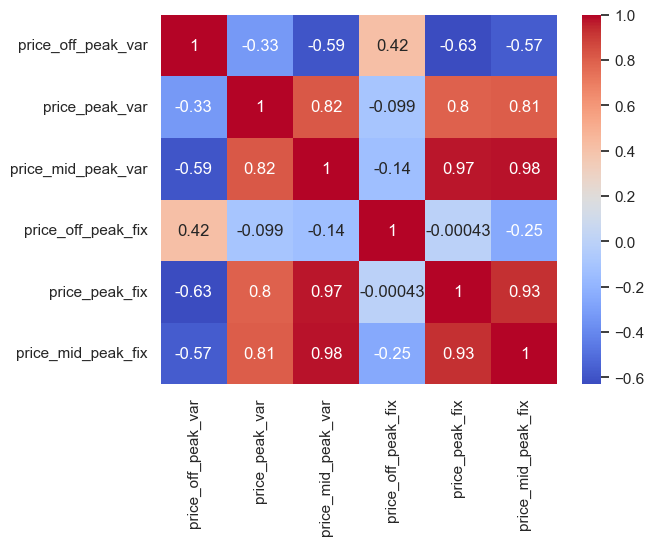

In [30]:
corr = price.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

- Presence of **multicollinearity among peak and mid-peak features**: Indicates closely linked pricing structure across peak periods
- Very high correlation between price_peak_fix ↔ price_mid_peak_fix (0.93)
- **Off-peak variable price is negatively correlated with most other features**
- **Weak or near-zero correlation between off-peak fixed and peak fixed**


### **Fixed vs Variable Price Analysis**

<Axes: xlabel='price_off_peak_var', ylabel='price_off_peak_fix'>

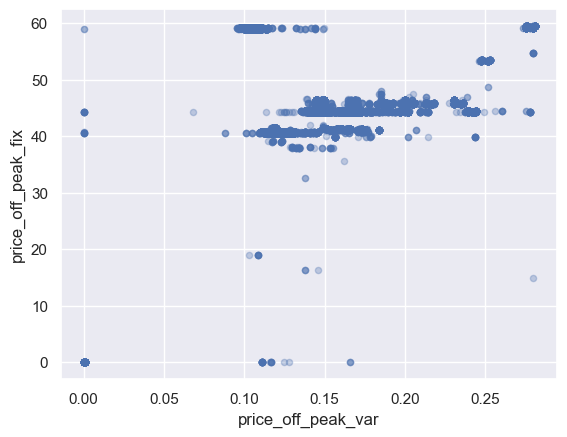

In [31]:
price.plot.scatter(x='price_off_peak_var', y='price_off_peak_fix', alpha=0.3)

Overall relationship is not strongly linear, suggesting:
- Fixed and variable prices are partially independent
- Clustering pattern confirms customer segmentation in pricing models

### **Forecast & Reality Price Comparison**

In [32]:
actual = price.groupby("id", as_index=False).agg({"price_off_peak_var": "mean"})
forecast = client[["id", "forecast_price_energy_off_peak"]]
df_compare = actual.merge(forecast, on="id", how="inner")

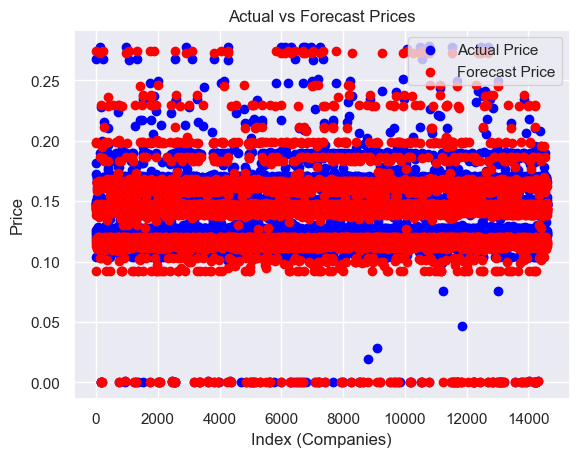

In [33]:
plt.figure()

# Actual values (blue)
plt.scatter(
    df_compare.index,
    df_compare["price_off_peak_var"],
    color="blue",
    label="Actual Price")

# Forecast values (red)
plt.scatter(
    df_compare.index,
    df_compare["forecast_price_energy_off_peak"],
    color="red",
    label="Forecast Price")

plt.xlabel("Index (Companies)")
plt.ylabel("Price")
plt.title("Actual vs Forecast Prices")

plt.legend()
plt.show()

- Forecast values appear more clustered compared to actual values, indicating that the model may be smoothing predictions and not fully capturing variability.
- Several zero values are present in both datasets, which could represent missing data, inactive accounts, or data quality issues.
- A slight upward bias is observed in forecast values, suggesting that the model tends to overestimate prices in some cases.

> Overall, the model performs reasonably well in capturing general trends but shows limitations in variability, bias, and handling edge cases.

-----

## **Key Business Insights**

### **1. Tenure is the strongest churn indicator**
Customers with shorter tenure have significantly higher churn rates.

> **Business Action:** Focus retention efforts on customers within the first 1–2 years.

### **2. Service bundling reduces churn**
Customers subscribed to both electricity and gas are less likely to churn.

> **Business Action:** Promote bundled service packages to increase retention.

### **3. Price is not the primary driver**
Although pricing contributes to churn, it is not the dominant factor.

> **Business Action:** Instead of price cuts, focus on customer experience and engagement.

### **4. High consumption ≠ high churn**
High-usage customers are not necessarily more likely to churn.

> **Business Action:** Avoid targeting customers solely based on consumption levels.


### **5. Early-stage customers are high-risk**
Churn risk is highest shortly after acquisition.

> **Business Action:** Implement onboarding and early engagement strategies.

---

### **Data Cleaning**

In [34]:
client["date_activ"] = pd.to_datetime(client["date_activ"])
client["date_end"] = pd.to_datetime(client["date_end"])
client["date_modif_prod"] = pd.to_datetime(client["date_modif_prod"])
client["date_renewal"] = pd.to_datetime(client["date_renewal"])
price["price_date"] = pd.to_datetime(price["price_date"])

In [35]:
#Beyond 5 active products were treated as a single group

client['prod_group'] = client['nb_prod_act'].apply(lambda x: x if x < 5 else '5')
client['prod_group'] = pd.to_numeric(client['prod_group'], errors='coerce')
client.prod_group.value_counts

<bound method IndexOpsMixin.value_counts of 0        2
1        1
2        1
3        1
4        1
        ..
14601    2
14602    1
14603    1
14604    1
14605    1
Name: prod_group, Length: 14606, dtype: int64>

In [36]:
client.channel_sales.value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [37]:
# Channel Sales Data Cleaned
channel_mapping = {  'MISSING': 'Missing',
    'ewpakwlliwisiwduibdlfmalxowmwpci': 'Channel A',
    'foosdfpfkusacimwkcsosbicdxkicaua': 'Channel B',
    'lmkebamcaaclubfxadlmueccxoimlema': 'Channel C',
    'usilxuppasemubllopkaafesmlibmsdf': 'Channel D'}

# Keep only rows in mapping
client = client[client["channel_sales"].isin(channel_mapping.keys())]

# Map values
client["channel_sales"] = client["channel_sales"].map(channel_mapping)


In [38]:
#Origin Up Data Cleaned
client.origin_up.value_counts()

origin_up
lxidpiddsbxsbosboudacockeimpuepw    7094
kamkkxfxxuwbdslkwifmmcsiusiuosws    4292
ldkssxwpmemidmecebumciepifcamkci    3137
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

In [39]:
channel_mapping = {  'MISSING': 'Missing',
    "lxidpiddsbxsbosboudacockeimpuepw" : "origin_3",
    "kamkkxfxxuwbdslkwifmmcsiusiuosws" : "origin_1",
    "ldkssxwpmemidmecebumciepifcamkci" : "origin_2"}

# Keep only rows in mapping
client = client[client["origin_up"].isin(channel_mapping.keys())]

# Map values
client["origin_up"] = client["origin_up"].map(channel_mapping)

-----
## **Feature Engineering**

### **Numerical Data Transformation**

In [40]:
#Highly right skewed histogram: Apply Log Transformation
skewed_cols = ["imp_cons", "cons_12m", "cons_last_month", "cons_gas_12m"]

for col in skewed_cols:
    if col in client.columns:
        client[col] = np.log1p(client[col])

### **Categorical Data Transformation**

In [41]:
# One Hot Encoding
features= ['origin_up',"channel_sales"]
for column in features:
    client = pd.get_dummies(client, columns=[column])

### **Feature Creation**

In [42]:
# create energy consumption feature
client['cons_change'] = (client['cons_last_month'] - client['cons_12m'])
client['cons_ratio'] = (client['cons_last_month'] / (client['cons_12m'] + 1e-5))

# create gas consumption feature
client["total_energy"] = ( client["cons_12m"] + client["cons_gas_12m"]) 

In [43]:
#Create Price Sensitivity Feature

# Estimated bill WITH discount
client["estimated_bill"] = (
    client["forecast_cons_12m"] *
    (client["forecast_price_energy_peak"] + client["forecast_price_energy_off_peak"]) / 2
) - client["forecast_discount_energy"]

# Estimated bill WITHOUT discount
client["estimated_bill_no_discount"] = (
    client["forecast_cons_12m"] *
    (client["forecast_price_energy_peak"] + client["forecast_price_energy_off_peak"]) / 2)

In [44]:
# Create Interaction Feature : Capacity * price
client["cost_pressure"] = client["pow_max"] * client["forecast_price_pow_off_peak"]

In [45]:
#Create Profitability Feature
client["cost_per_year"] = client["cost_pressure"] / (client["num_years_antig"] + 1)
client["net_value_score"] = client["net_margin"] - client["cost_pressure"]

In [46]:
#Create Dates Feature
client["days_from_modif"] = (client["date_end"] - client["date_modif_prod"]).dt.days
client["days_from_renewal"] = (client["date_renewal"] - client["date_end"]).dt.days

In [47]:
# Difference between off-peak prices between January & December feature

#Include only ids present in client dataset
price = price[price["id"].isin(client["id"])]

# Extract month
price["month"] = price["price_date"].dt.month

# Seperate monthly prices
monthly = price.groupby(["id", "month"], as_index=False).agg({
    "price_off_peak_var": "mean",
    "price_off_peak_fix": "mean"})

# Get Jan and Dec directly
jan = monthly[monthly["month"] == 1]
dec = monthly[monthly["month"] == 12]

# Merge and compute differences
jan = jan.dropna(subset=["price_off_peak_var", "price_off_peak_fix"])
dec = dec.dropna(subset=["price_off_peak_var", "price_off_peak_fix"])

diff = jan.merge(dec, on="id", how="inner", suffixes=("_jan", "_dec"))

diff["off_var"] = diff["price_off_peak_var_dec"] - diff["price_off_peak_var_jan"]
diff["off_fix"] = diff["price_off_peak_fix_dec"] - diff["price_off_peak_fix_jan"]

# Keep only needed columns
diff = diff[["id", "off_var", "off_fix"]]

# Merge with main data
client = client.merge(diff, on="id", how="right")

client.head()


,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,total_energy,estimated_bill,estimated_bill_no_discount,cost_pressure,cost_per_year,net_value_score,days_from_modif,days_from_renewal,off_var,off_fix
0,0002203ffbb812588b632b9e628cc38d,10.000387,0.0,8.034307,2010-01-19,2016-02-21,2010-01-19,2015-02-25,729.06,425,...,10.000387,79.072025,79.072025,700.465592,100.066513,-619.045592,2224,-361,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,8.309185,0.0,0.000000,2009-08-06,2016-06-21,2013-06-21,2015-06-23,597.77,0,...,8.309185,42.461098,42.461098,584.910189,83.558598,-523.330189,1096,-364,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,8.914761,0.0,6.968850,2013-02-25,2016-05-05,2015-05-05,2015-02-26,1311.16,1062,...,8.914761,100.611203,130.611203,634.700101,158.675025,-553.090101,366,-434,0.050443,1.500000
3,00114d74e963e47177db89bc70108537,9.330166,0.0,0.000000,2010-03-02,2016-03-02,2010-03-02,2015-03-09,1671.41,0,...,9.330166,120.466040,120.466040,584.910189,83.558598,-426.920189,2192,-359,-0.003994,-0.000001
4,0013f326a839a2f6ad87a1859952d227,12.496557,0.0,9.872771,2013-02-22,2016-02-22,2014-10-07,2015-02-26,3077.34,1760,...,12.496557,339.101327,339.101327,812.134020,203.033505,-470.554020,503,-361,-0.006171,0.000000


In [48]:
#Difference between peak prices between January & December Feature

#Include only ids present in client dataset
price = price[price["id"].isin(client["id"])]

# Extract month
price["month"] = price["price_date"].dt.month

# Seperate monthly prices
monthly = price.groupby(["id", "month"], as_index=False).agg({
    "price_peak_var": "mean",
    "price_peak_fix": "mean"})

# Get Jan and Dec directly
jan = monthly[monthly["month"] == 1]
dec = monthly[monthly["month"] == 12]

# Merge and compute differences
jan = jan.dropna(subset=["price_peak_var", "price_peak_fix"])
dec = dec.dropna(subset=["price_peak_var", "price_peak_fix"])

diff = jan.merge(dec, on="id", how="inner", suffixes=("_jan", "_dec"))

diff["peak_var"] = diff["price_peak_var_dec"] - diff["price_peak_var_jan"]
diff["peak_fix"] = diff["price_peak_fix_dec"] - diff["price_peak_fix_jan"]

# Keep only needed columns
diff = diff[["id", "peak_var", "peak_fix"]]

# Merge with main data
client = client.merge(diff, on="id", how="right")

client.head()



,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,estimated_bill_no_discount,cost_pressure,cost_per_year,net_value_score,days_from_modif,days_from_renewal,off_var,off_fix,peak_var,peak_fix
0,0002203ffbb812588b632b9e628cc38d,10.000387,0.0,8.034307,2010-01-19,2016-02-21,2010-01-19,2015-02-25,729.06,425,...,79.072025,700.465592,100.066513,-619.045592,2224,-361,-0.006192,0.162916,-0.002302,0.097749
1,0004351ebdd665e6ee664792efc4fd13,8.309185,0.0,0.000000,2009-08-06,2016-06-21,2013-06-21,2015-06-23,597.77,0,...,42.461098,584.910189,83.558598,-523.330189,1096,-364,-0.004104,0.177779,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,8.914761,0.0,6.968850,2013-02-25,2016-05-05,2015-05-05,2015-02-26,1311.16,1062,...,130.611203,634.700101,158.675025,-553.090101,366,-434,0.050443,1.500000,0.000000,0.000000
3,00114d74e963e47177db89bc70108537,9.330166,0.0,0.000000,2010-03-02,2016-03-02,2010-03-02,2015-03-09,1671.41,0,...,120.466040,584.910189,83.558598,-426.920189,2192,-359,-0.003994,-0.000001,0.000000,0.000000
4,0013f326a839a2f6ad87a1859952d227,12.496557,0.0,9.872771,2013-02-22,2016-02-22,2014-10-07,2015-02-26,3077.34,1760,...,339.101327,812.134020,203.033505,-470.554020,503,-361,-0.006171,0.000000,-0.002351,0.000000


In [49]:
# Difference between mid peak prices between January & December Feature

#Include only ids present in client dataset
price = price[price["id"].isin(client["id"])]

# Extract month
price["month"] = price["price_date"].dt.month

# Seperate monthly prices
monthly = price.groupby(["id", "month"], as_index=False).agg({
    "price_mid_peak_var": "mean",
    "price_mid_peak_fix": "mean"})

# Get Jan and Dec directly
jan = monthly[monthly["month"] == 1]
dec = monthly[monthly["month"] == 12]

# Merge and compute differences
jan = jan.dropna(subset=["price_mid_peak_var", "price_mid_peak_fix"])
dec = dec.dropna(subset=["price_mid_peak_var", "price_mid_peak_fix"])

diff = jan.merge(dec, on="id", how="inner", suffixes=("_jan", "_dec"))

diff["mid_var"] = diff["price_mid_peak_var_dec"] - diff["price_mid_peak_var_jan"]
diff["mid_fix"] = diff["price_mid_peak_fix_dec"] - diff["price_mid_peak_fix_jan"]

# Keep only needed columns
diff = diff[["id", "mid_var", "mid_fix"]]

# Merge with main data
client = client.merge(diff, on="id", how="right")

client.head()

,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,cost_per_year,net_value_score,days_from_modif,days_from_renewal,off_var,off_fix,peak_var,peak_fix,mid_var,mid_fix
0,0002203ffbb812588b632b9e628cc38d,10.000387,0.0,8.034307,2010-01-19,2016-02-21,2010-01-19,2015-02-25,729.06,425,...,100.066513,-619.045592,2224,-361,-0.006192,0.162916,-0.002302,0.097749,0.003487,0.065166
1,0004351ebdd665e6ee664792efc4fd13,8.309185,0.0,0.000000,2009-08-06,2016-06-21,2013-06-21,2015-06-23,597.77,0,...,83.558598,-523.330189,1096,-364,-0.004104,0.177779,0.000000,0.000000,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,8.914761,0.0,6.968850,2013-02-25,2016-05-05,2015-05-05,2015-02-26,1311.16,1062,...,158.675025,-553.090101,366,-434,0.050443,1.500000,0.000000,0.000000,0.000000,0.000000
3,00114d74e963e47177db89bc70108537,9.330166,0.0,0.000000,2010-03-02,2016-03-02,2010-03-02,2015-03-09,1671.41,0,...,83.558598,-426.920189,2192,-359,-0.003994,-0.000001,0.000000,0.000000,0.000000,0.000000
4,0013f326a839a2f6ad87a1859952d227,12.496557,0.0,9.872771,2013-02-22,2016-02-22,2014-10-07,2015-02-26,3077.34,1760,...,203.033505,-470.554020,503,-361,-0.006171,0.000000,-0.002351,0.000000,0.003371,0.000000


In [50]:
# Monthly price max for each price range Feature

# Seperate monthly prices per id
mean_prices_by_month = ( price.groupby(["id", "price_date"])
    .agg( off_var=("price_off_peak_var", "mean"),
        peak_var=("price_peak_var", "mean"),
        mid_var=("price_mid_peak_var", "mean"),
        off_fix=("price_off_peak_fix", "mean"),
        peak_fix=("price_peak_fix", "mean"),
        mid_fix=("price_mid_peak_fix", "mean"),
    ).reset_index())

# max(off_peak - mid_peak of each month)
# Create energy differences features
mean_prices_by_month["mon_off_peak_var"] = (
    mean_prices_by_month["off_var"] - mean_prices_by_month["peak_var"])

mean_prices_by_month["mon_peak_mid_var"] = (
    mean_prices_by_month["peak_var"] - mean_prices_by_month["mid_var"])

mean_prices_by_month["mon_off_mid_var"] = (
    mean_prices_by_month["off_var"] - mean_prices_by_month["mid_var"])

# Power differences
mean_prices_by_month["mon_off_peak_fix"] = (
    mean_prices_by_month["off_fix"] - mean_prices_by_month["peak_fix"])

mean_prices_by_month["mon_peak_mid_fix"] = (
    mean_prices_by_month["peak_fix"] - mean_prices_by_month["mid_fix"])

mean_prices_by_month["mon_off_mid_fix"] = (
    mean_prices_by_month["off_fix"] - mean_prices_by_month["mid_fix"])

# Seperate max differences per id
max_diff = ( mean_prices_by_month.groupby("id")[
        [   "mon_off_peak_var",
            "mon_peak_mid_var",
            "mon_off_mid_var",
            "mon_off_peak_fix",
            "mon_peak_mid_fix",
            "mon_off_mid_fix", ]
    ].max().reset_index())

# Rename columns cleanly
max_diff = max_diff.rename(columns=lambda x: f"{x}_max" if x != "id" else x)

# Merge
client = client.merge(max_diff, on="id", how="left")

print(client.shape)
client.head()

(14566, 56)


,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,peak_var,peak_fix,mid_var,mid_fix,mon_off_peak_var_max,mon_peak_mid_var_max,mon_off_mid_var_max,mon_off_peak_fix_max,mon_peak_mid_fix_max,mon_off_mid_fix_max
0,0002203ffbb812588b632b9e628cc38d,10.000387,0.0,8.034307,2010-01-19,2016-02-21,2010-01-19,2015-02-25,729.06,425,...,-0.002302,0.097749,0.003487,0.065166,0.022225,0.033743,0.055866,16.291555,8.145775,24.437330
1,0004351ebdd665e6ee664792efc4fd13,8.309185,0.0,0.000000,2009-08-06,2016-06-21,2013-06-21,2015-06-23,597.77,0,...,0.000000,0.000000,0.000000,0.000000,0.148405,0.000000,0.148405,44.444710,0.000000,44.444710
2,0010bcc39e42b3c2131ed2ce55246e3c,8.914761,0.0,6.968850,2013-02-25,2016-05-05,2015-05-05,2015-02-26,1311.16,1062,...,0.000000,0.000000,0.000000,0.000000,0.205742,0.000000,0.205742,45.944710,0.000000,45.944710
3,00114d74e963e47177db89bc70108537,9.330166,0.0,0.000000,2010-03-02,2016-03-02,2010-03-02,2015-03-09,1671.41,0,...,0.000000,0.000000,0.000000,0.000000,0.149902,0.000000,0.149902,44.266931,0.000000,44.266931
4,0013f326a839a2f6ad87a1859952d227,12.496557,0.0,9.872771,2013-02-22,2016-02-22,2014-10-07,2015-02-26,3077.34,1760,...,-0.002351,0.000000,0.003371,0.000000,0.022226,0.033675,0.055729,16.291555,8.145775,24.437330


### **Post EDA & Feature Selection**

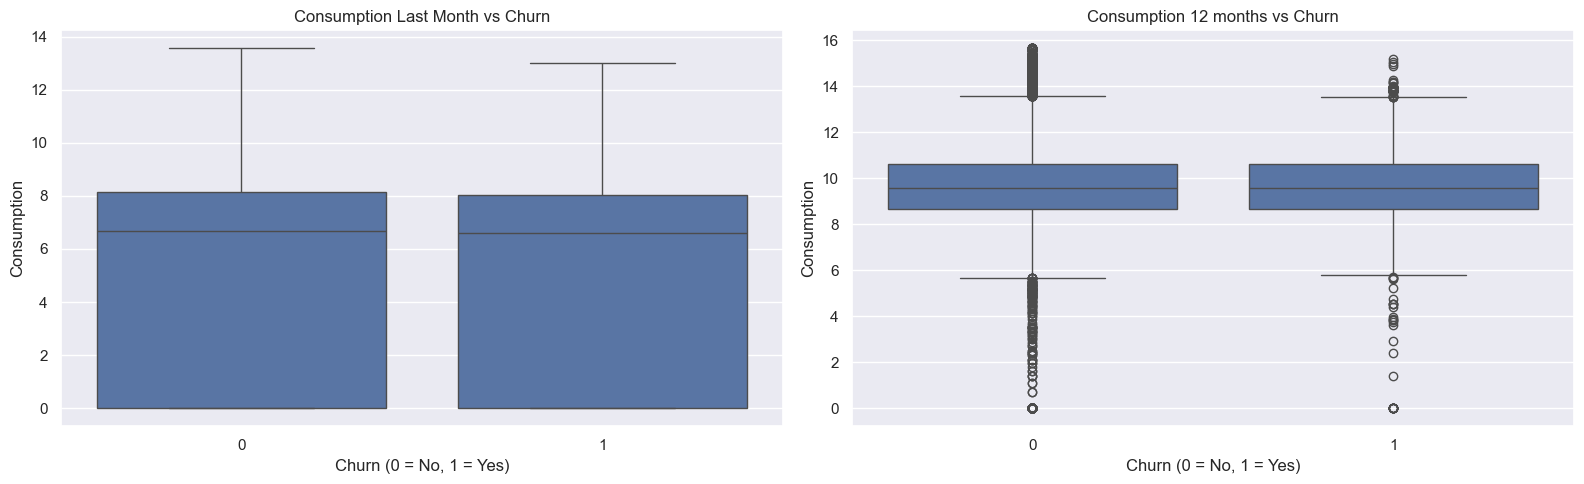

In [51]:
# Energy Consumption Analysis
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Log-transformed last month electricity consumption
sns.boxplot(x="churn", y="cons_last_month", data=client, ax=axes[0])
axes[0].set_title("Consumption Last Month vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Consumption")

# Log-transformed electricity consumption
sns.boxplot(x="churn", y="cons_12m", data=client, ax=axes[1])
axes[1].set_title("Consumption 12 months vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Consumption")

plt.tight_layout()
plt.show()

> Consumption alone is not a strong predictor of churn and should be combined with other behavioral or contextual features for effective modeling.

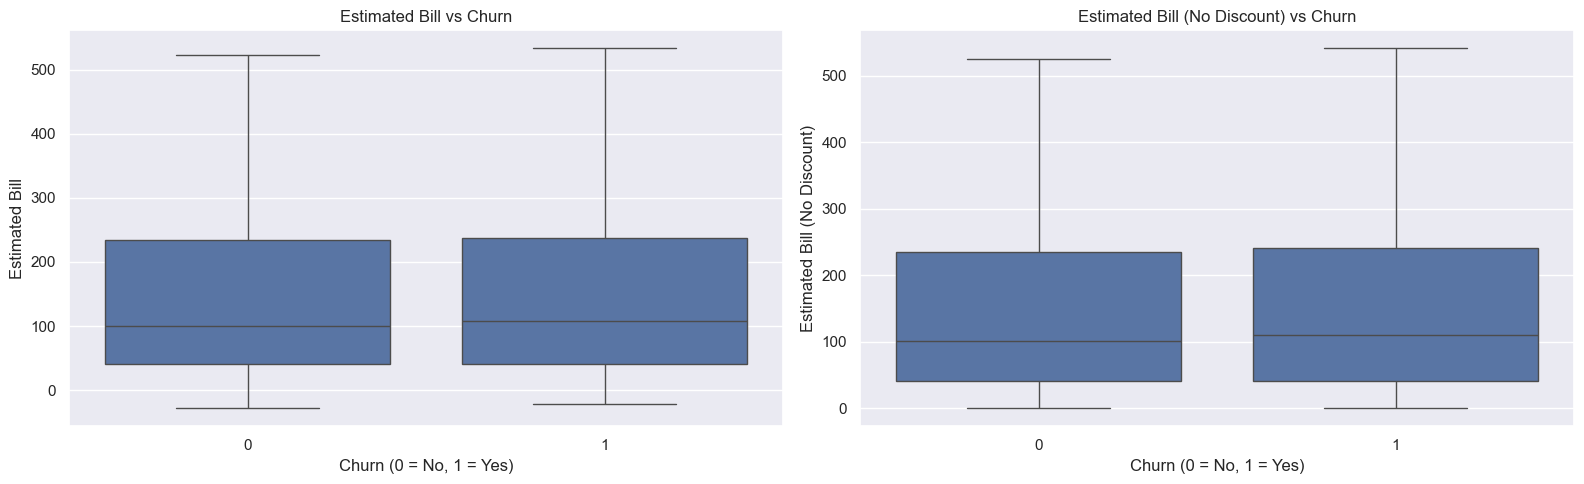

In [52]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Plot 1: With discount
sns.boxplot(x="churn", y="estimated_bill", data=client, ax=axes[0], showfliers=False)
axes[0].set_title("Estimated Bill vs Churn")
axes[0].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[0].set_ylabel("Estimated Bill")

# Plot 2: Without discount
sns.boxplot(x="churn", y="estimated_bill_no_discount", data=client, ax=axes[1], showfliers=False)
axes[1].set_title("Estimated Bill (No Discount) vs Churn")
axes[1].set_xlabel("Churn (0 = No, 1 = Yes)")
axes[1].set_ylabel("Estimated Bill (No Discount)")

# Show BOTH together
plt.tight_layout()
plt.show()

- A slight increase in churn was observed for higher billing segments.
- Removing discounts did not significantly change the distribution.

>**Price contributes to churn, but is not the dominant factor.** Discounts are not strongly influencing customer retention behavior

In [53]:
column = ["date_end", "date_renewal", "date_modif_prod","date_activ",
          'estimated_bill_no_discount','forecast_discount_energy','margin_gross_pow_ele' ]
client.drop(columns=column, inplace = True)

<Axes: >

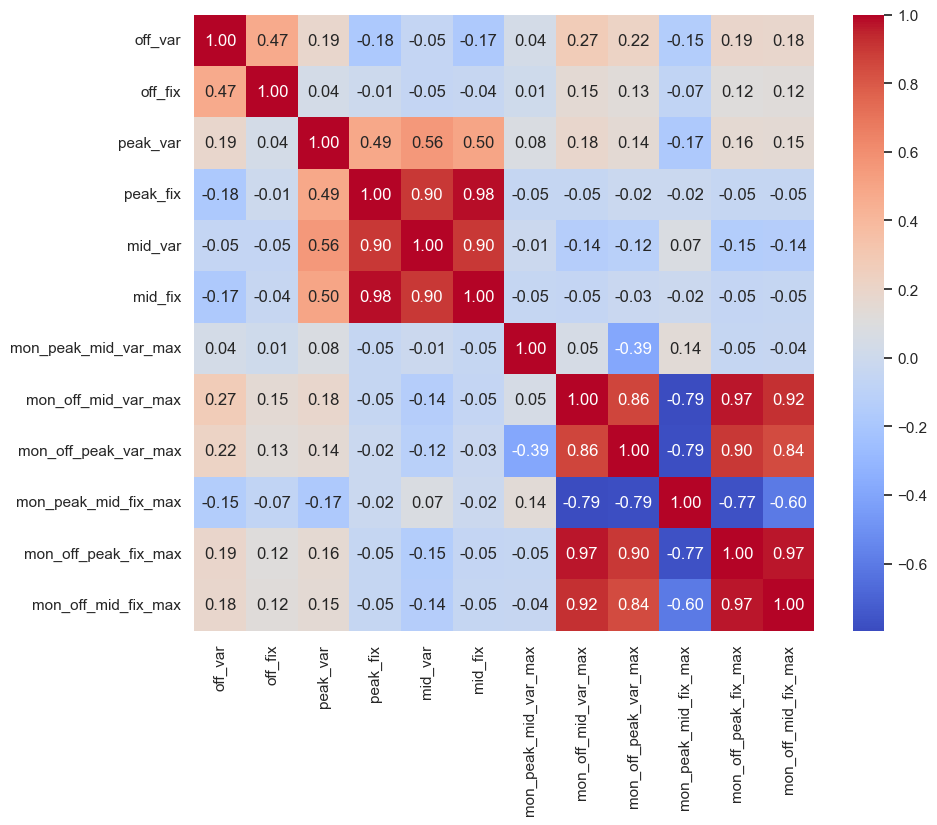

In [54]:
# Check correlation
diff = client[["off_var","off_fix","peak_var","peak_fix","mid_var","mid_fix",
               "mon_peak_mid_var_max","mon_off_mid_var_max","mon_off_peak_var_max",
               "mon_peak_mid_fix_max","mon_off_peak_fix_max","mon_off_mid_fix_max"] ].corr()
plt.figure(figsize=(10,8))
sns.heatmap(diff, annot=True, cmap='coolwarm',fmt=".2f")

In [55]:
#Drop Columns
drop_cols = ["peak_fix", "mid_fix",
    "mon_off_mid_var_max","mon_off_peak_fix_max","mon_off_mid_fix_max"]

client = client.drop(columns=drop_cols, errors="ignore")

<Axes: >

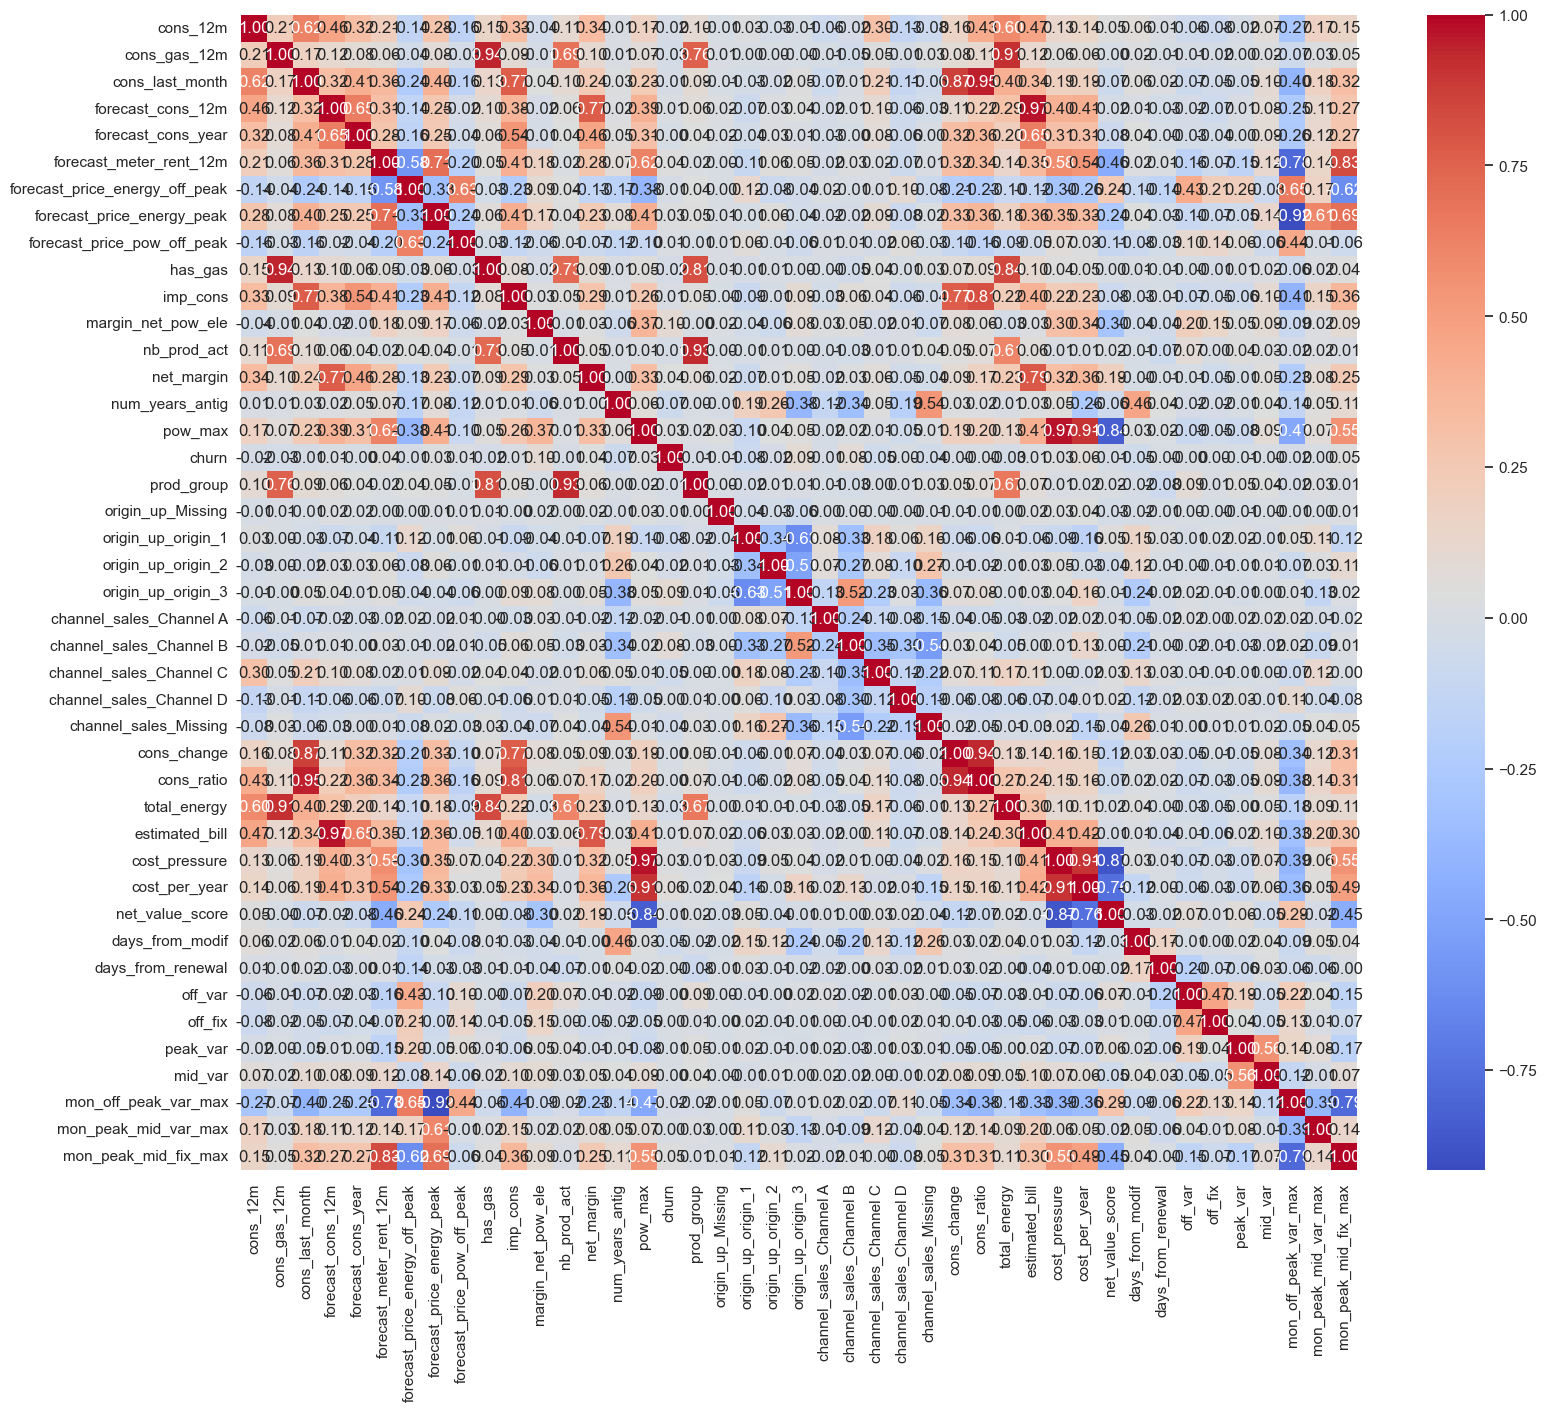

In [56]:
# Check correlation
diff = client.corr(numeric_only=True)
plt.figure(figsize=(18,15))
sns.heatmap(diff, annot=True, cmap='coolwarm',fmt=".2f")

In [57]:
#Drop Column
client.drop(columns=["pow_max","forecast_cons_12m", "forecast_cons_year",
                     "has_gas"], inplace = True)

In [58]:
client.columns

Index(['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'imp_cons',
       'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig',
       'churn', 'prod_group', 'origin_up_Missing', 'origin_up_origin_1',
       'origin_up_origin_2', 'origin_up_origin_3', 'channel_sales_Channel A',
       'channel_sales_Channel B', 'channel_sales_Channel C',
       'channel_sales_Channel D', 'channel_sales_Missing', 'cons_change',
       'cons_ratio', 'total_energy', 'estimated_bill', 'cost_pressure',
       'cost_per_year', 'net_value_score', 'days_from_modif',
       'days_from_renewal', 'off_var', 'off_fix', 'peak_var', 'mid_var',
       'mon_off_peak_var_max', 'mon_peak_mid_var_max', 'mon_peak_mid_fix_max'],
      dtype='str')

### **Feature Importance Analysis**

In [59]:
X = client.drop(["churn", "id"], axis=1)
y = client["churn"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

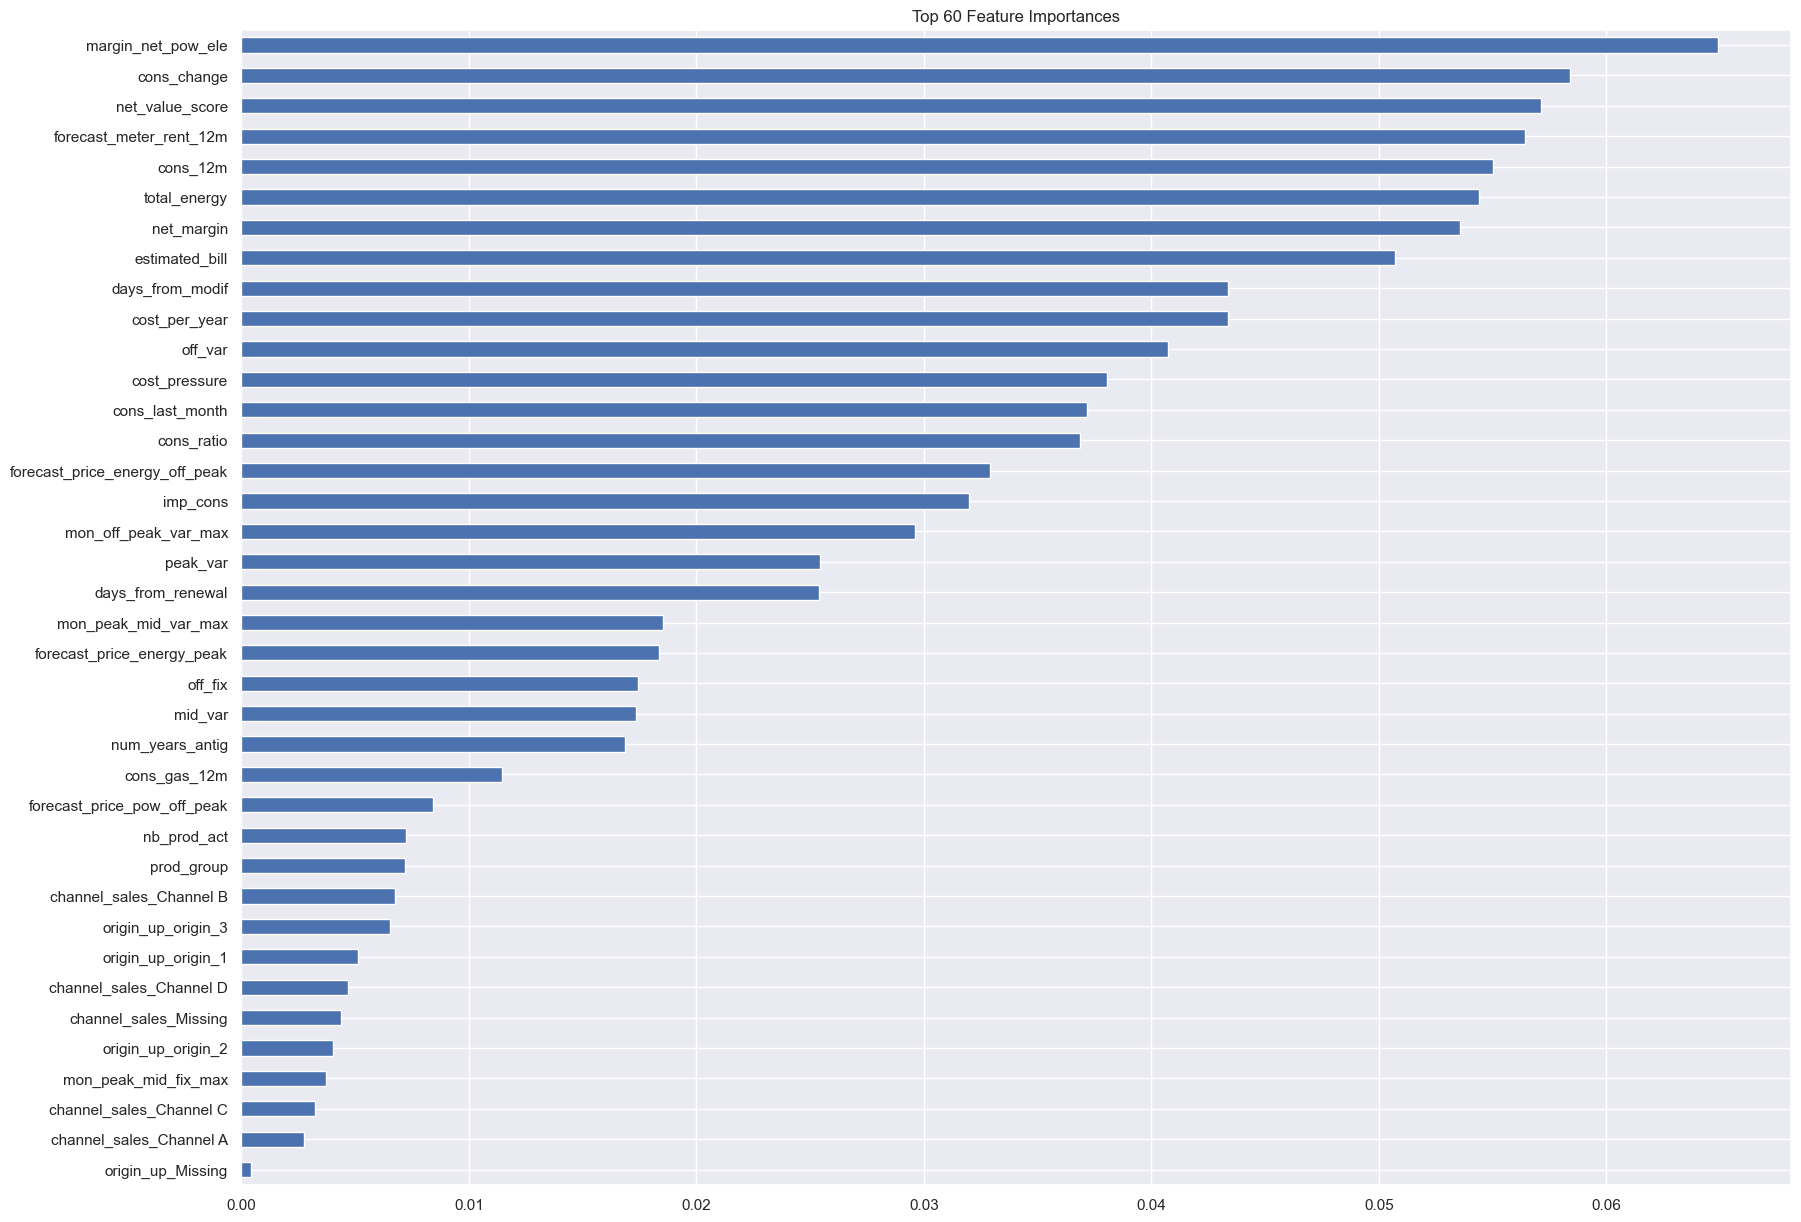

In [60]:
# Train
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(60).plot(
    kind="barh",
    figsize=(20,15))

plt.gca().invert_yaxis()
plt.title("Top 60 Feature Importances")
plt.show()

### **Feature Importance Insights**

The model indicates that churn is influenced more by **behavioral and temporal features** than raw consumption or pricing.

Key drivers include:
- Customer tenure (num_years_antig)
- Contract-related dates (renewal, activation)
- Net margin and engagement indicators
- Forecast-related features

> Top features confirm that tenure and contract-related variables dominate churn prediction.


In [61]:
drop_cols = [col for col in client.columns
    if "origin_up" in col
    or "channel_sales" in col]

client = client.drop(columns=drop_cols, errors="ignore")

-------
# **Model Training & Evaluation**

In [62]:
X = client.drop(["churn", "id"], axis=1)
y = client["churn"]
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(11652, 29)
(11652,)
(2914, 29)
(2914,)


## **Random Forest Model**

In [63]:
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
#Class imbalance handling by class_weight

RandomForestClassifier(class_weight='balanced')

In [64]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2626    0]
 [ 268   20]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2626
           1       1.00      0.07      0.13       288

    accuracy                           0.91      2914
   macro avg       0.95      0.53      0.54      2914
weighted avg       0.92      0.91      0.87      2914



### **Only Threshold tuning RF Model**

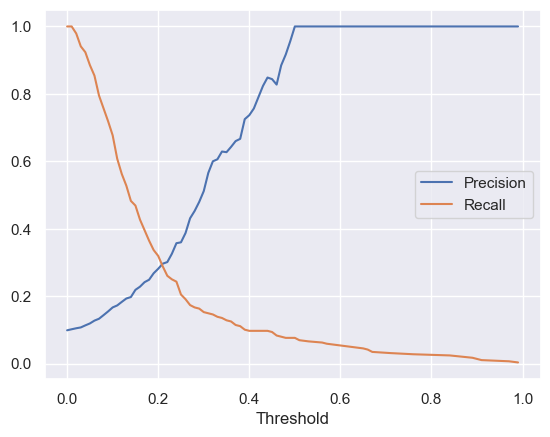

In [65]:
y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [66]:
threshold = 0.2
y_pred = (y_probs >= threshold).astype(int)

matrix1 = confusion_matrix(y_test, y_pred)
report1 = classification_report(y_test, y_pred)

print(matrix1)
print(report1)

[[2391  235]
 [ 196   92]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      2626
           1       0.28      0.32      0.30       288

    accuracy                           0.85      2914
   macro avg       0.60      0.61      0.61      2914
weighted avg       0.86      0.85      0.86      2914



In [67]:
threshold = 0.23
y_pred = (y_probs >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2477  149]
 [ 216   72]]
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2626
           1       0.33      0.25      0.28       288

    accuracy                           0.87      2914
   macro avg       0.62      0.60      0.61      2914
weighted avg       0.86      0.87      0.87      2914



- Evaluated performance using precision, recall, and F1-score instead of accuracy

| Threshold | Precision (1) | Recall (1) | F1-score (1) | Accuracy |
| --------- | ------------- | ---------- | ------------ | -------- |
| 0.23     | **0.29**          | 0.32       | 0.30         | 0.85     |
| 0.20      | 0.28        | **0.34**   | **0.30**     | 0.85     |


Selected threshold = 0.20 as it provides the best trade-off.

### **Smote Sampling + Threshold Tuning RF Model**

In [68]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_res.value_counts())

churn
0    10523
1     1129
Name: count, dtype: int64
churn
0    10523
1    10523
Name: count, dtype: int64


In [69]:
model.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced')

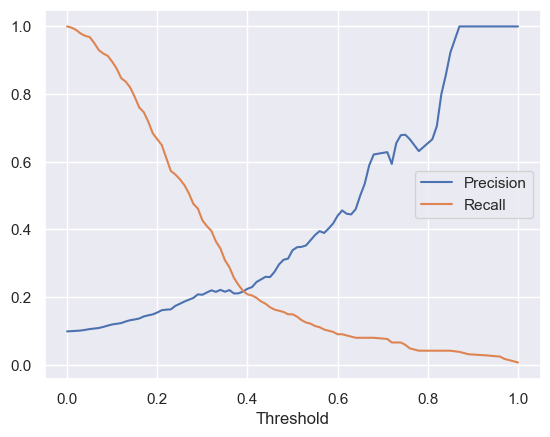

In [70]:
y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [71]:
for t in [0.35, 0.4, 0.45]:
    y_pred = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2626
           1       0.22      0.31      0.25       288

    accuracy                           0.82      2914
   macro avg       0.57      0.59      0.58      2914
weighted avg       0.85      0.82      0.83      2914


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      2626
           1       0.22      0.21      0.22       288

    accuracy                           0.85      2914
   macro avg       0.57      0.56      0.57      2914
weighted avg       0.85      0.85      0.85      2914


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2626
           1       0.26      0.17      0.21       288

    accuracy                           0.87      2914
   macro avg       0.59      0.56      0.57      2914
weighted avg       0.85 

- To address class imbalance, SMOTE was applied to balance the training data, followed by threshold tuning.

Evaluated multiple thresholds (0.30, 0.35, 0.40)

| Threshold | Precision (1) | Recall (1) | F1-score (1) |
| --------- | ------------- | ---------- | ------------ |
| 0.35     | 0.21          | **0.30**   | **0.25**     |
| 0.40      | 0.24          | 0.23       | 0.24         |
| 0.45      | **0.28**          | 0.18       | 0.22         |

Selected threshold = 0.35 as it:

Note: SMOTE sometimes adds synthetic noise, causes overfitting, hurts precision

### **Comparison**
| Approach      | Precision (1) | Recall (1) | F1-score (1) |
| ------------- | ------------- | ---------- | ------------ |
| With SMOTE    | 0.21          | 0.30   | 0.25         |
| Without SMOTE | **0.28**      | **0.34**       | **0.30**     |

The **Only Threshold tuning Model** was selected as the final model

## **Final RF Model**

In [72]:
rf_model = RandomForestClassifier(  
    class_weight='balanced',
    n_estimators=5000,
    max_features='sqrt',
    random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=5000,
                       random_state=42)

In [91]:
y_probs = rf_model.predict_proba(X_test)[:, 1]
threshold = 0.2
y_pred = (y_probs > threshold).astype(int)

matrix2 = confusion_matrix(y_test, y_pred)
report2 = classification_report(y_test, y_pred)

print(matrix2)
print(report2)

[[2443  183]
 [ 204   84]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2626
           1       0.31      0.29      0.30       288

    accuracy                           0.87      2914
   macro avg       0.62      0.61      0.61      2914
weighted avg       0.86      0.87      0.86      2914



**Random Forest Model Final Performance**
- `Recall (Class 1): 0.30`
- `Precision (Class 1): 0.33`
- `F1-score: 0.31`
- `Accuracy: 0.87`

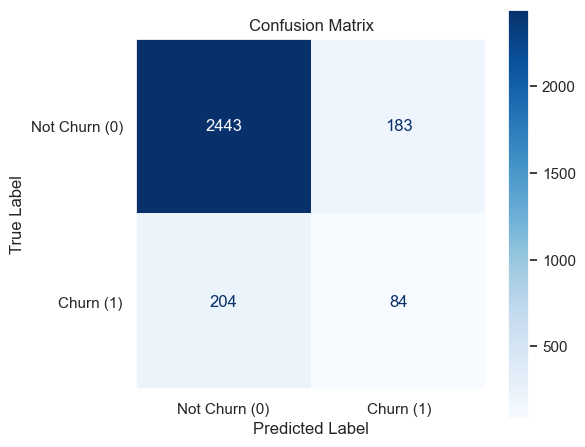

In [92]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix2,
    display_labels=['Not Churn (0)', 'Churn (1)']
)

disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")
ax.grid(False)

plt.tight_layout()
plt.show()

> The confusion matrix highlights the model’s ability to detect churn customers, while also showing the trade-off between false positives and false negatives.

## **XGBoost Model**

In [74]:
xgb_model = XGBClassifier(
    scale_pos_weight=9,
    random_state=42)
xgb_model.fit(X_train, y_train)
#class imbalance handling by scale_pos_weight

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [75]:
y_pred = xgb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2406  220]
 [ 207   81]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2626
           1       0.27      0.28      0.28       288

    accuracy                           0.85      2914
   macro avg       0.59      0.60      0.60      2914
weighted avg       0.86      0.85      0.85      2914



### **Only Threshold Tuning XG Model**

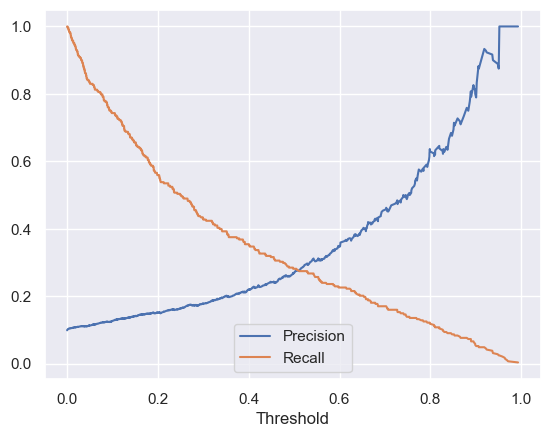

In [76]:
y_probs = xgb_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [77]:
y_probs = xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.54
y_pred = (y_probs > threshold).astype(int)

matrix2 = confusion_matrix(y_test, y_pred)
report2 = classification_report(y_test, y_pred)

print(matrix2)
print(report2)

[[2453  173]
 [ 211   77]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2626
           1       0.31      0.27      0.29       288

    accuracy                           0.87      2914
   macro avg       0.61      0.60      0.61      2914
weighted avg       0.86      0.87      0.86      2914



### **Final XG Model**

In [78]:
xgb_model1 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=8,
    gamma=0,               
    min_child_weight=1,   
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha = 0.5, #L1 regularisation
    reg_lambda = 1.5, #L2 regularization
    eval_metric='aucpr',             
    random_state=42)
xgb_model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [79]:
y_probs = xgb_model1.predict_proba(X_test)[:, 1]
threshold = 0.3
y_pred = (y_probs > threshold).astype(int)

matrix2 = confusion_matrix(y_test, y_pred)
report2 = classification_report(y_test, y_pred)

print(matrix2)
print(report2)

[[2392  234]
 [ 195   93]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      2626
           1       0.28      0.32      0.30       288

    accuracy                           0.85      2914
   macro avg       0.60      0.62      0.61      2914
weighted avg       0.86      0.85      0.86      2914



**XGBoost Final Performance**
- `Recall (Class 1): 0.32`
- `Precision (Class 1): 0.28`
- `F1-score: 0.30`
- `Accuracy: 0.85`

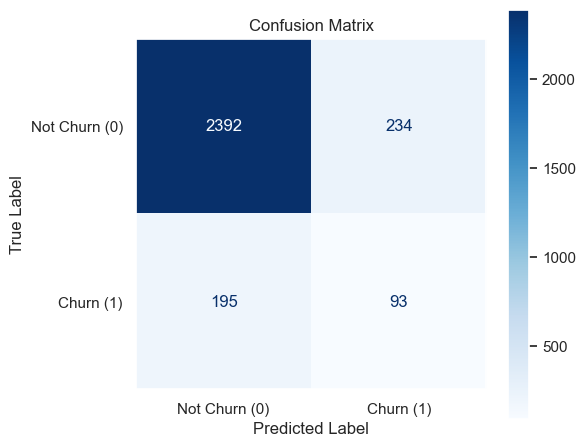

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix2,
    display_labels=['Not Churn (0)', 'Churn (1)']
)

disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")
ax.grid(False)

plt.tight_layout()
plt.show()

> The confusion matrix highlights the model’s ability to detect churn customers, while also showing the trade-off between false positives and false negatives.

## **Final Conclusion**

Both Random Forest and XGBoost models were tuned and evaluated with a focus on improving performance for the minority (churn) class.

| Model         | Precision | Recall   | F1-score | Accuracy |
|--------------|----------|---------|---------|---------|
| Random Forest | **0.33** | 0.30    | **0.31** | **0.87** |
| XGBoost       | 0.28     | **0.32** | 0.30     | 0.85     |

Both models show similar performance, with a trade-off between precision and recall:

- XGBoost achieves higher recall, identifying more churn customers  
- Random Forest achieves higher precision and F1-score, providing a better balance between false positives and false negatives  
- Random Forest also delivers higher overall accuracy  

### **Final Model Selection**

The **Random Forest model** was selected as the final model because it provides the most balanced and reliable performance:

- Highest F1-score (0.31), ensuring a good balance between precision and recall  
- Higher precision, reducing unnecessary targeting of non-churn customers  
- Strong overall accuracy (0.87)  
- More stable and interpretable compared to XGBoost  

### **Why Model Performance is Moderate**

Despite tuning both models, performance remains moderate. This indicates:

- The dataset lacks strong predictive signals  
- Feature quality is the primary limitation  
- Further improvements depend on **feature engineering rather than model complexity**  

> This highlights a key real-world insight: better data often matters more than more complex algorithms.

---

# **Business Recommendations**

Based on the analysis and model results:

### **1. Focus on early retention**
- Target customers within the first 12–24 months  
- Provide onboarding incentives  

### **2. Promote bundled services**
- Encourage electricity + gas subscriptions  
- Offer bundled pricing incentives  

### **3. Improve customer engagement**
- Identify low-engagement customers  
- Introduce loyalty and retention programs  

### **4. Avoid over-reliance on pricing strategies**
- Price changes alone are insufficient to reduce churn  
- Focus on service quality and customer experience  

### **5. Use the model for proactive targeting**
- Identify high-risk customers before renewal  
- Deploy targeted retention campaigns  

---

## **Future Improvements**

To further enhance model performance:

- Develop advanced behavioral features  
- Incorporate customer interaction data (calls, complaints, support tickets)  
- Apply time-series modeling for price trends  
- Experiment with ensemble techniques  
- Use cost-sensitive learning for class imbalance  

> The next stage of improvement lies in **data enrichment and feature engineering**, not just model complexity.

### **Final Takeaway**

Even with moderate predictive performance, the model provides meaningful business value by enabling early identification of churn risk and supporting data-driven retention strategies.